In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folder_path_o = os.path.join('COVID-19-Wearables')
files = [file for file in os.listdir(folder_path_o) if file.endswith('_hr.csv')]

In [3]:
# gather descriptive statistics from all CSVs in `files` (folder_path_o) into one dataframe

stats = []
box_list = []

for fname in files:
    fpath = os.path.join(folder_path_o, fname)
    try:
        df = pd.read_csv(fpath, low_memory=False)
    except Exception as e:
        # skip files that can't be read
        print(f"skipping {fname}: {e}")
        continue

    participant = fname.replace('_hr.csv', '')
    if participant in ['AJ7TSV9','AS2MVDL', 'APGIB2T']:
        print(f"skipping {fname}: known bad file")
        continue
    
    # numeric summary (keeps previous behavior)
    numeric = df.select_dtypes(include='number')
    if not numeric.empty:
        desc = numeric.describe().T  # index = column names
        for col, row in desc.iterrows():
            stats.append({
                'participant': participant,
                'variable': col,
                'count': int(row['count']),
                'mean': row['mean'],
                'std': row['std'],
                'min': row['min'],
                '25%': row['25%'],
                '50%': row['50%'],
                '75%': row['75%'],
                'max': row['max'],
            })

        # long form needed for boxplots: one row per measurement value
        long_df = numeric.melt(var_name='variable', value_name='value')
        # ensure numeric values and drop NaNs
        long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')
        long_df = long_df.dropna(subset=['value'])
        if not long_df.empty:
            long_df['participant'] = participant
            # keep only necessary columns for plotting
            box_list.append(long_df[['participant', 'variable', 'value']])

# final dataframes
stats_df = pd.DataFrame(stats)

if box_list:
    box_df = pd.concat(box_list, ignore_index=True)
else:
    box_df = pd.DataFrame(columns=['participant', 'variable', 'value'])


skipping AJ7TSV9_hr.csv: known bad file
skipping AS2MVDL_hr.csv: known bad file
skipping APGIB2T_hr.csv: known bad file


In [4]:
stats_df.head()

,participant,variable,count,mean,std,min,25%,50%,75%,max
0,AUY8KYW,heartrate,928969,66.628707,16.705457,41.0,55.0,63.0,73.0,186.0
1,A0NVTRV,heartrate,372105,81.940092,11.235566,53.0,74.0,80.0,88.0,206.0
2,AYWIEKR,heartrate,866821,81.604058,14.833436,54.0,70.0,79.0,89.0,178.0
3,A4G0044,heartrate,124190,71.190716,14.598931,46.0,61.0,68.0,77.0,182.0
4,A1K5DRI,heartrate,887558,79.230898,14.091042,50.0,69.0,77.0,87.0,180.0


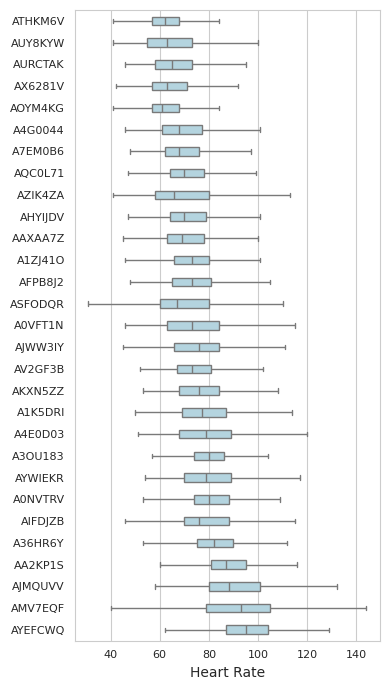

In [5]:
# boxplot por paciente (filtra apenas heartrate se houver outras variáveis)
# agora invertemos os eixos: heartrate no eixo x e paciente no eixo y
hr_df = box_df[box_df['variable'] == 'heartrate']

# ordenar pacientes por média (opcional, usa stats_df já calculado)
order = stats_df.sort_values('mean')['participant'].tolist()

sns.set_style("whitegrid")
plt.figure(figsize=(4, 7))
sns.boxplot(data=hr_df, x='value', y='participant', order=order, showfliers=False, width=.4, color='lightblue')
plt.yticks(rotation=0)
plt.xlabel('Heart Rate')
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# plt.title('Boxplot por paciente (heartrate) — eixos invertidos')
plt.tight_layout()


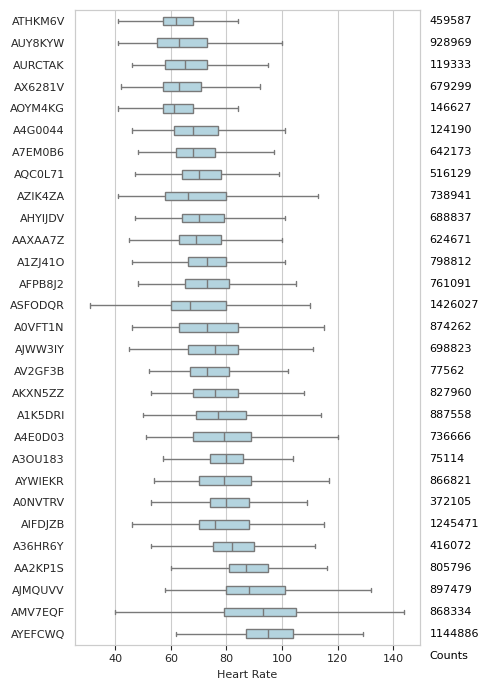

In [6]:
fig, ax1 = plt.subplots(figsize=(5, 7))

sns.boxplot(
    data=hr_df, x='value', y='participant',
    order=order, showfliers=False, width=.4, color='lightblue', ax=ax1
)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.ylabel('')

ax2 = ax1.twiny()  # cria eixo X secundário (acima)
ax2.set_xlim(ax1.get_xlim())

counts = stats_df.set_index('participant')['count']
ax2.set_xticks([])

for i, p in enumerate(order):
    ax2.text(153, i, f"{counts[p]}", 
             va='center', ha='left', fontsize=8, color='black')
    
ax2.text(153, len(order), "Counts", 
             va='center', ha='left', fontsize=8, color='black')

ax1.set_xlabel("Heart Rate", fontsize=8)

plt.tight_layout()
# plt.savefig('Plots/boxplot_heart_rate.eps', dpi=300)
plt.show()


In [7]:
# compute mean interval (in seconds and minutes) between consecutive datetime rows for each file
mean_intervals = []

for fname in files:
    fpath = os.path.join(folder_path_o, fname)
    participant = fname.replace('_hr.csv', '')

    df_time = pd.read_csv(fpath, usecols=['datetime'], low_memory=False)
    times = pd.to_datetime(df_time['datetime'], errors='coerce').dropna().sort_values()
    
    diffs = times.diff().dt.total_seconds().dropna()
    mean_seconds = float(diffs.mean())

    mean_intervals.append({
        'participant': participant,
        'mean_interval_seconds': round(mean_seconds,1),
        # 'mean_interval_minutes': round(mean_seconds / 60, 1) if pd.notna(mean_seconds) else pd.NA,
        'mean_std_seconds': round(diffs.std(),1),
        'median_interval_seconds': round(diffs.median(),1),
        'days_span': round((times.max() - times.min()).total_seconds() / 86400, 1),
        'n_timestamps': len(times),
    })

mean_intervals_df = pd.DataFrame(mean_intervals).set_index('participant').sort_values('mean_interval_seconds')
mean_intervals_df.head()

,mean_interval_seconds,mean_std_seconds,median_interval_seconds,days_span,n_timestamps
participant,,,,,
ASFODQR,7.8,58.3,5.0,129.0,1426027
AFPB8J2,8.1,36.2,5.0,71.0,761091
A4E0D03,8.2,16.0,5.0,70.0,736666
AAXAA7Z,8.3,15.7,5.0,60.0,624671
AX6281V,8.3,23.4,5.0,65.0,679299


In [8]:
interval_list = []

for fname in files:
    participant = fname.replace('_hr.csv', '')
    if participant in ['AJ7TSV9', 'AS2MVDL', 'APGIB2T']:
        continue
    fpath = os.path.join(folder_path_o, fname)
    try:
        df_t = pd.read_csv(fpath, usecols=['datetime'], low_memory=False)
    except Exception:
        continue

    times = pd.to_datetime(df_t['datetime'], errors='coerce').dropna().sort_values()
    diffs = times.diff().dt.total_seconds().dropna()
    if not diffs.empty:
        interval_list.append(pd.DataFrame({
            'participant': participant,
            'interval_seconds': diffs.values
        }))

if interval_list:
    intervals_df = pd.concat(interval_list, ignore_index=True)
else:
    intervals_df = pd.DataFrame(columns=['participant', 'interval_seconds'])

# quick boxplot of intervals per participant (ordered by mean interval)
# order = intervals_df.groupby('participant')['interval_seconds'].mean().sort_values().index.tolist()

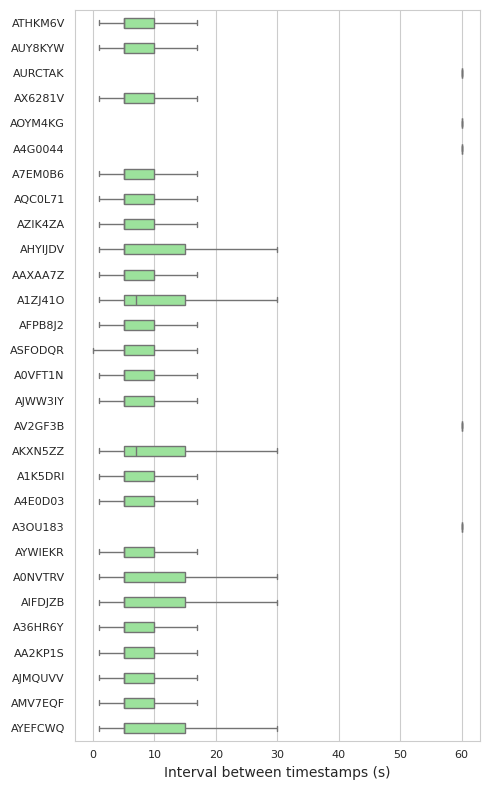

In [9]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 8))
sns.boxplot(
    data=intervals_df, x='interval_seconds', y='participant',
    order=order, showfliers=False, width=.4, color='lightgreen'
)
plt.xlabel('Interval between timestamps (s)')
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

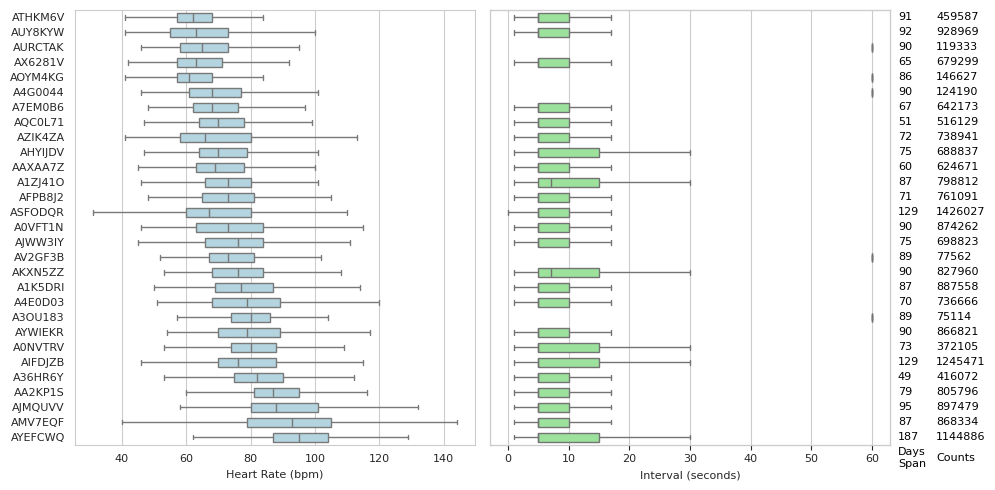

In [12]:

# ordenar pacientes por média (opcional, usa stats_df já calculado)
order = stats_df.sort_values('mean')['participant'].tolist()
# unified figure: heart rate (left) and interval (right) boxplots sharing y-axis
fig, (ax_hr, ax_int) = plt.subplots(ncols=2, sharey=True, figsize=(10, 5))

sns.set_style("whitegrid")

sns.boxplot(
    data=hr_df, x='value', y='participant', order=order,
    showfliers=False, width=.6, color='lightblue', ax=ax_hr
)
ax_hr.set_xlabel('Heart Rate (bpm)', fontsize=8)
ax_hr.set_ylabel('')
ax_hr.tick_params(axis='x', labelsize=8)
ax_hr.tick_params(axis='y', labelsize=8)

sns.boxplot(
    data=intervals_df, x='interval_seconds', y='participant', order=order,
    showfliers=False, width=.6, color='lightgreen', ax=ax_int
)
ax_int.set_xlabel('Interval (seconds)', fontsize=8)
ax_int.set_ylabel('')
ax_int.tick_params(axis='x', labelsize=8)
ax_int.tick_params(axis='y', labelsize=8)

# add two auxiliary x-axes on the interval plot to display Days Span and Counts
ax_top = ax_int.twiny()
ax_top.set_xlim(ax_int.get_xlim())
ax_top.set_xticks([])

ax_top2 = ax_top.twiny()
ax_top2.set_xlim(ax_int.get_xlim())
ax_top2.set_xticks([])

# map participant -> days span (use mean_intervals_df computed earlier)
# convert to dict so lookups like span[p] work robustly
span = mean_intervals_df['days_span'].to_dict()
counts = mean_intervals_df['n_timestamps'].to_dict()

# choose positions for the annotations relative to the interval x-axis max
x0, x1 = ax_int.get_xlim()
pos_span = x1 * 1.02
pos_counts = x1 * 1.12

for i, p in enumerate(order):
    ax_top.text(pos_span, i, f"{int(span[p]):g}", va='center', ha='left', fontsize=8, color='black')
ax_top.text(pos_span, len(order), "\nDays\nSpan", va='center', ha='left', fontsize=8, color='black')

for i, p in enumerate(order):
    ax_top2.text(pos_counts, i, f"{counts[p]}", va='center', ha='left', fontsize=8, color='black')
ax_top2.text(pos_counts, len(order), "\nCounts", va='center', ha='left', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('Plots/boxplot_unified.eps', dpi=300)
plt.show()

In [ ]:
# gather descriptive statistics from all CSVs in `files` (folder_path_o) into one dataframe

stats = []
box_list = []

folder_path_o = os.path.join('COVID-19-Wearables')
files = [file for file in os.listdir(folder_path_o) if file.endswith('_steps.csv')]

for fname in files:
    fpath = os.path.join(folder_path_o, fname)
    try:
        df = pd.read_csv(fpath, low_memory=False)
    except Exception as e:
        # skip files that can't be read
        print(f"skipping {fname}: {e}")
        continue

    participant = fname.replace('_steps.csv', '')
    if participant in ['AJ7TSV9','AS2MVDL', 'APGIB2T']:
        print(f"skipping {fname}: known bad file")
        continue
    
    # numeric summary (keeps previous behavior)
    numeric = df.select_dtypes(include='number')
    if not numeric.empty:
        desc = numeric.describe().T  # index = column names
        for col, row in desc.iterrows():
            stats.append({
                'participant': participant,
                'variable': col,
                'count': int(row['count']),
                'mean': row['mean'],
                'std': row['std'],
                'min': row['min'],
                '25%': row['25%'],
                '50%': row['50%'],
                '75%': row['75%'],
                'max': row['max'],
            })

        # long form needed for boxplots: one row per measurement value
        long_df = numeric.melt(var_name='variable', value_name='value')
        # ensure numeric values and drop NaNs
        long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')
        long_df = long_df.dropna(subset=['value'])
        if not long_df.empty:
            long_df['participant'] = participant
            # keep only necessary columns for plotting
            box_list.append(long_df[['participant', 'variable', 'value']])

# final dataframes
stats_df = pd.DataFrame(stats)

if box_list:
    box_df = pd.concat(box_list, ignore_index=True)
else:
    box_df = pd.DataFrame(columns=['participant', 'variable', 'value'])


skipping APGIB2T_steps.csv: known bad file
skipping AS2MVDL_steps.csv: known bad file
skipping AJ7TSV9_steps.csv: known bad file


In [ ]:
steps_df = box_df[box_df['variable'] == 'steps']
stats_df

,participant,variable,count,mean,std,min,25%,50%,75%,max
0,AOYM4KG,steps,120960,5.642419,19.606535,0.0,0.0,0.0,0.0,176.0
1,AAXAA7Z,steps,86340,8.418242,24.241775,0.0,0.0,0.0,0.0,189.0
2,AV2GF3B,steps,129540,3.288127,12.600406,0.0,0.0,0.0,0.0,145.0
3,AX6281V,steps,93540,4.085717,16.705959,0.0,0.0,0.0,0.0,166.0
4,AMV7EQF,steps,103620,6.454488,18.931591,0.0,0.0,0.0,0.0,174.0
5,AKXN5ZZ,steps,129540,2.783526,11.128776,0.0,0.0,0.0,0.0,201.0
6,A1K5DRI,steps,126720,5.049811,17.522329,0.0,0.0,0.0,0.0,180.0
7,AZIK4ZA,steps,103680,9.773573,25.262827,0.0,0.0,0.0,6.0,155.0
8,A0NVTRV,steps,94980,2.823794,11.443562,0.0,0.0,0.0,0.0,154.0
9,AYEFCWQ,steps,272160,2.221135,9.630333,0.0,0.0,0.0,0.0,1046.0


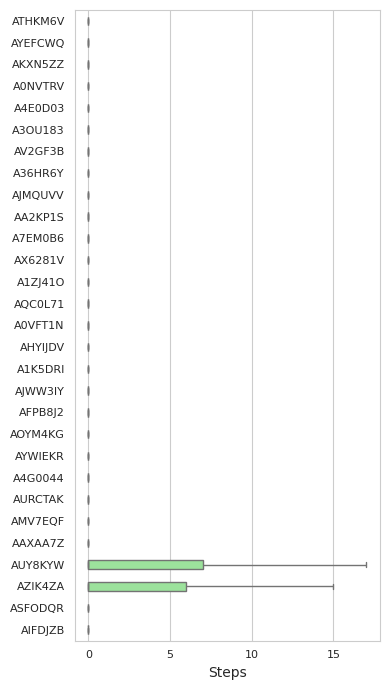

In [ ]:

# ordenar pacientes por média (opcional, usa stats_df já calculado)
order = stats_df.sort_values('mean')['participant'].tolist()

sns.set_style("whitegrid")
plt.figure(figsize=(4, 7))
sns.boxplot(data=steps_df, x='value', y='participant', order=order, showfliers=False, width=.4, color='lightgreen')
plt.yticks(rotation=0)
plt.xlabel('Steps')
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# plt.title('Boxplot por paciente (heartrate) — eixos invertidos')
plt.tight_layout()

In [ ]:
mean_intervals = []

for fname in files:
    fpath = os.path.join(folder_path_o, fname)
    participant = fname.replace('_steps.csv', '')

    df_time = pd.read_csv(fpath, usecols=['datetime'], low_memory=False)
    times = pd.to_datetime(df_time['datetime'], errors='coerce').dropna().sort_values()
    
    diffs = times.diff().dt.total_seconds().dropna()
    mean_seconds = float(diffs.mean())

    mean_intervals.append({
        'participant': participant,
        'mean_interval_seconds': round(mean_seconds,1),
        # 'mean_interval_minutes': round(mean_seconds / 60, 1) if pd.notna(mean_seconds) else pd.NA,
        'mean_std_seconds': round(diffs.std(),1),
        'median_interval_seconds': round(diffs.median(),1),
        'days_span': round((times.max() - times.min()).total_seconds() / 86400, 1),
        'n_timestamps': len(times),
    })

mean_intervals_df = pd.DataFrame(mean_intervals).set_index('participant').sort_values('mean_interval_seconds')
mean_intervals_df.head()

,mean_interval_seconds,mean_std_seconds,median_interval_seconds,days_span,n_timestamps
participant,,,,,
AOYM4KG,60.0,0.0,60.0,84.0,120960
AIFDJZB,60.0,8.4,60.0,129.0,185720
ATHKM6V,60.0,0.0,60.0,91.0,131040
ASFODQR,60.0,8.4,60.0,129.0,185757
A3OU183,60.0,10.0,60.0,90.0,129540


In [ ]:
mean_intervals_df.head(29)

,mean_interval_seconds,mean_std_seconds,median_interval_seconds,days_span,n_timestamps
participant,,,,,
AOYM4KG,60.0,0.0,60.0,84.0,120960
AIFDJZB,60.0,8.4,60.0,129.0,185720
ATHKM6V,60.0,0.0,60.0,91.0,131040
ASFODQR,60.0,8.4,60.0,129.0,185757
A3OU183,60.0,10.0,60.0,90.0,129540
A4E0D03,60.0,12.4,60.0,59.0,84900
AHYIJDV,60.0,11.0,60.0,75.0,107940
A1ZJ41O,60.0,10.2,60.0,87.0,125220
AJWW3IY,60.0,11.0,60.0,75.0,107940


In [ ]:
interval_list = []

for fname in files:
    participant = fname.replace('_steps.csv', '')
    if participant in ['AJ7TSV9', 'AS2MVDL', 'APGIB2T']:
        continue
    fpath = os.path.join(folder_path_o, fname)
    try:
        df_t = pd.read_csv(fpath, usecols=['datetime'], low_memory=False)
    except Exception:
        continue

    times = pd.to_datetime(df_t['datetime'], errors='coerce').dropna().sort_values()
    diffs = times.diff().dt.total_seconds().dropna()
    if not diffs.empty:
        interval_list.append(pd.DataFrame({
            'participant': participant,
            'interval_seconds': diffs.values
        }))

if interval_list:
    intervals_df = pd.concat(interval_list, ignore_index=True)
else:
    intervals_df = pd.DataFrame(columns=['participant', 'interval_seconds'])

# quick boxplot of intervals per participant (ordered by mean interval)
# order = intervals_df.groupby('participant')['interval_seconds'].mean().sort_values().index.tolist()

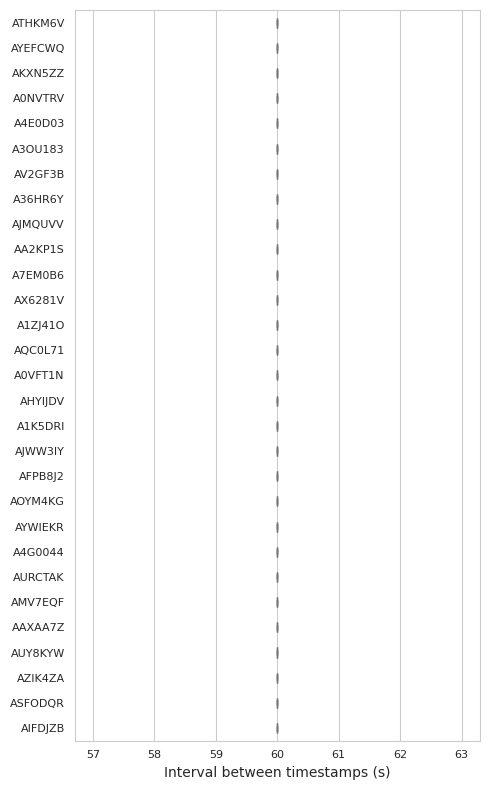

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 8))
sns.boxplot(
    data=intervals_df, x='interval_seconds', y='participant',
    order=order, showfliers=False, width=.4, color='lightgreen'
)
plt.xlabel('Interval between timestamps (s)')
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()